# Gemini Quant Challenge — Market-Making Demo

Project: **3rd place out of 50 teams** at the *Gemini Collegiate Quant Trading Competition* (Feb 15 – Apr 15, 2026). Team **Moon Shot** (Columbia MSFE).

The competition was conducted on the **live Gemini exchange** with a $3,000 cash advance per team. Daily scoring formula: `Volume × (1 + ROE)²`, with the total score being the sum of each team's **5 best days**. Both volume and risk-adjusted return matter — a strategy that just churns volume with negative ROE is penalised.

This notebook walks through the backtest pipeline on 2 hours of XRP/USD data:
1. Load Gemini level-2 order-book data (NPZ format, hourly slices)
2. Run the **Avellaneda-Stoikov** market-making strategy
3. Inspect PnL, inventory dynamics, fills, and risk metrics
4. Run a small Bayesian-optimisation example over the strategy's hyperparameters, using the competition's actual scoring rule as the objective

Reading time: ~2 minutes. Total execution: ~30s. See `README.md` for the full project story (including the late-stage rule change that forced a complete strategy pivot).

## 1. Setup

Imports the `mmbt` package (lives in `mm/mmbt/`). The framework is a thin pure-Python layer on top of [`hftbacktest`](https://github.com/nkaz001/hftbacktest), which provides a realistic exchange simulator (latency model, queue priority, fees).

In [1]:
import sys, os, logging
sys.path.insert(0, os.path.abspath('mm'))

from mmbt import (
    AssetConfig, BacktestRunner,
    AvellanedaStoikovStrategy, GTQBStrategy,
    BayesianOptimizer,
)

logging.basicConfig(level=logging.WARNING, format='%(levelname)s | %(message)s')

## 2. Configure the asset

We backtest on XRP/USD, two hours on 2026-03-08 (16:00 — 18:00 UTC). The microstructure parameters (`tick_size`, `lot_size`, fees) match Gemini's actual XRPUSD listing.

In [2]:
from pathlib import Path

asset = AssetConfig(
    symbol     = 'xrpusd',
    start_date = '20260308_16',
    end_date   = '20260308_18',
    tick_size  = 0.00001,
    lot_size   = 0.1,
    roi_lb     = 0.0,
    roi_ub     = 100.0,
    maker_fee  = 0.0005,
    taker_fee  = 0.001,
    data_dir   = Path('mm/data'),
)
asset

AssetConfig(symbol='xrpusd', start_date='20260308_16', end_date='20260308_18', tick_size=1e-05, lot_size=0.1, maker_fee=0.0005, taker_fee=0.001, latency_ns=100000000, roi_lb=0.0, roi_ub=100.0, last_trades_capacity=1000, data_dir=PosixPath('mm/data'))

## 3. Avellaneda-Stoikov strategy

Classical AS model with one tweak: σ is estimated online from a rolling window of mid-price levels, and `k` can be auto-calibrated from the message rate. The framework also supports pluggable alpha signals (e.g. order-book imbalance) added to the reservation price.

$$
r(s, q, t) = s - q\,\gamma\sigma^2 \tau + \alpha\\
\delta^a + \delta^b = \gamma\sigma^2 \tau + \tfrac{2}{\gamma}\ln\!\bigl(1 + \tfrac{\gamma}{k}\bigr)
$$

In [3]:
strat = AvellanedaStoikovStrategy(
    interval         = 100_000_000,   # 100 ms in nanoseconds
    gamma            = 0.0001,        # risk aversion
    k                = 2000.0,        # order-arrival intensity
    horizon          = 300.0,         # session horizon (seconds)
    order_qty_usd    = 100.0,         # $ notional per quote
    max_position_usd = 100_000.0,
    min_half_spread  = 0.00001,
)

result = BacktestRunner(
    assets    = [asset],
    strategy  = strat,
    book_size = 3_000.0,
    show_progress = False,
).run()

2026-05-25 14:16:08 | INFO | mmbt.runner | Backtest starting  |  strategy=AvellanedaStoikovStrategy  assets=XRPUSD  period=20260308_16 to 20260308_18  book_size=3000  estimated_steps=118000


2026-05-25 14:16:08 | INFO | mmbt.data.utils | Using hourly snapshot: xrpusd_20260308_160000_book.npz


2026-05-25 14:16:13 | INFO | mmbt.runner | ============================================================


2026-05-25 14:16:13 | INFO | mmbt.runner | Backtest complete  |  strategy=AvellanedaStoikovStrategy  assets=XRPUSD  runtime=4.53s


2026-05-25 14:16:13 | INFO | mmbt.runner | Period: 20260308_16 to 20260308_18  |  book_size=3000


...

2026-05-25 14:16:13 | INFO | mmbt.runner |   ReturnOverMDD                  0.665221


2026-05-25 14:16:13 | INFO | mmbt.runner |   ReturnOverTrade                0.001784


2026-05-25 14:16:13 | INFO | mmbt.runner |   MaxPositionValue               1304.686828


2026-05-25 14:16:13 | INFO | mmbt.runner |   DailyTradingVolume             11319.200000


2026-05-25 14:16:13 | INFO | mmbt.runner | ============================================================


## 4. Metrics

All metrics are computed by `hftbacktest.stats.LinearAssetRecord` from the recorded position/balance/fee/trade-count time series. `Return`, `MaxDrawdown`, and `DailyTurnover` are normalised by `book_size`.

In [4]:
import pandas as pd
pd.set_option('display.float_format', lambda x: f'{x:.4f}')
pd.DataFrame.from_dict(result.metrics, orient='index', columns=['value'])

,value
SR,25.5048
Sortino,35.3264
Return,0.0011
MaxDrawdown,0.0017
DailyNumberOfTrades,152.0000
DailyTurnover,5.0656
ReturnOverMDD,0.6652
ReturnOverTrade,0.0018
MaxPositionValue,1304.6868
DailyTradingVolume,11319.2000


## 5. Dashboard

One figure summarising: cumulative PnL (gross vs net of fees), inventory trajectory, quote placement vs mid, fill markers, and a few aggregate stats. Everything is reconstructed from the recorder output — no external state.

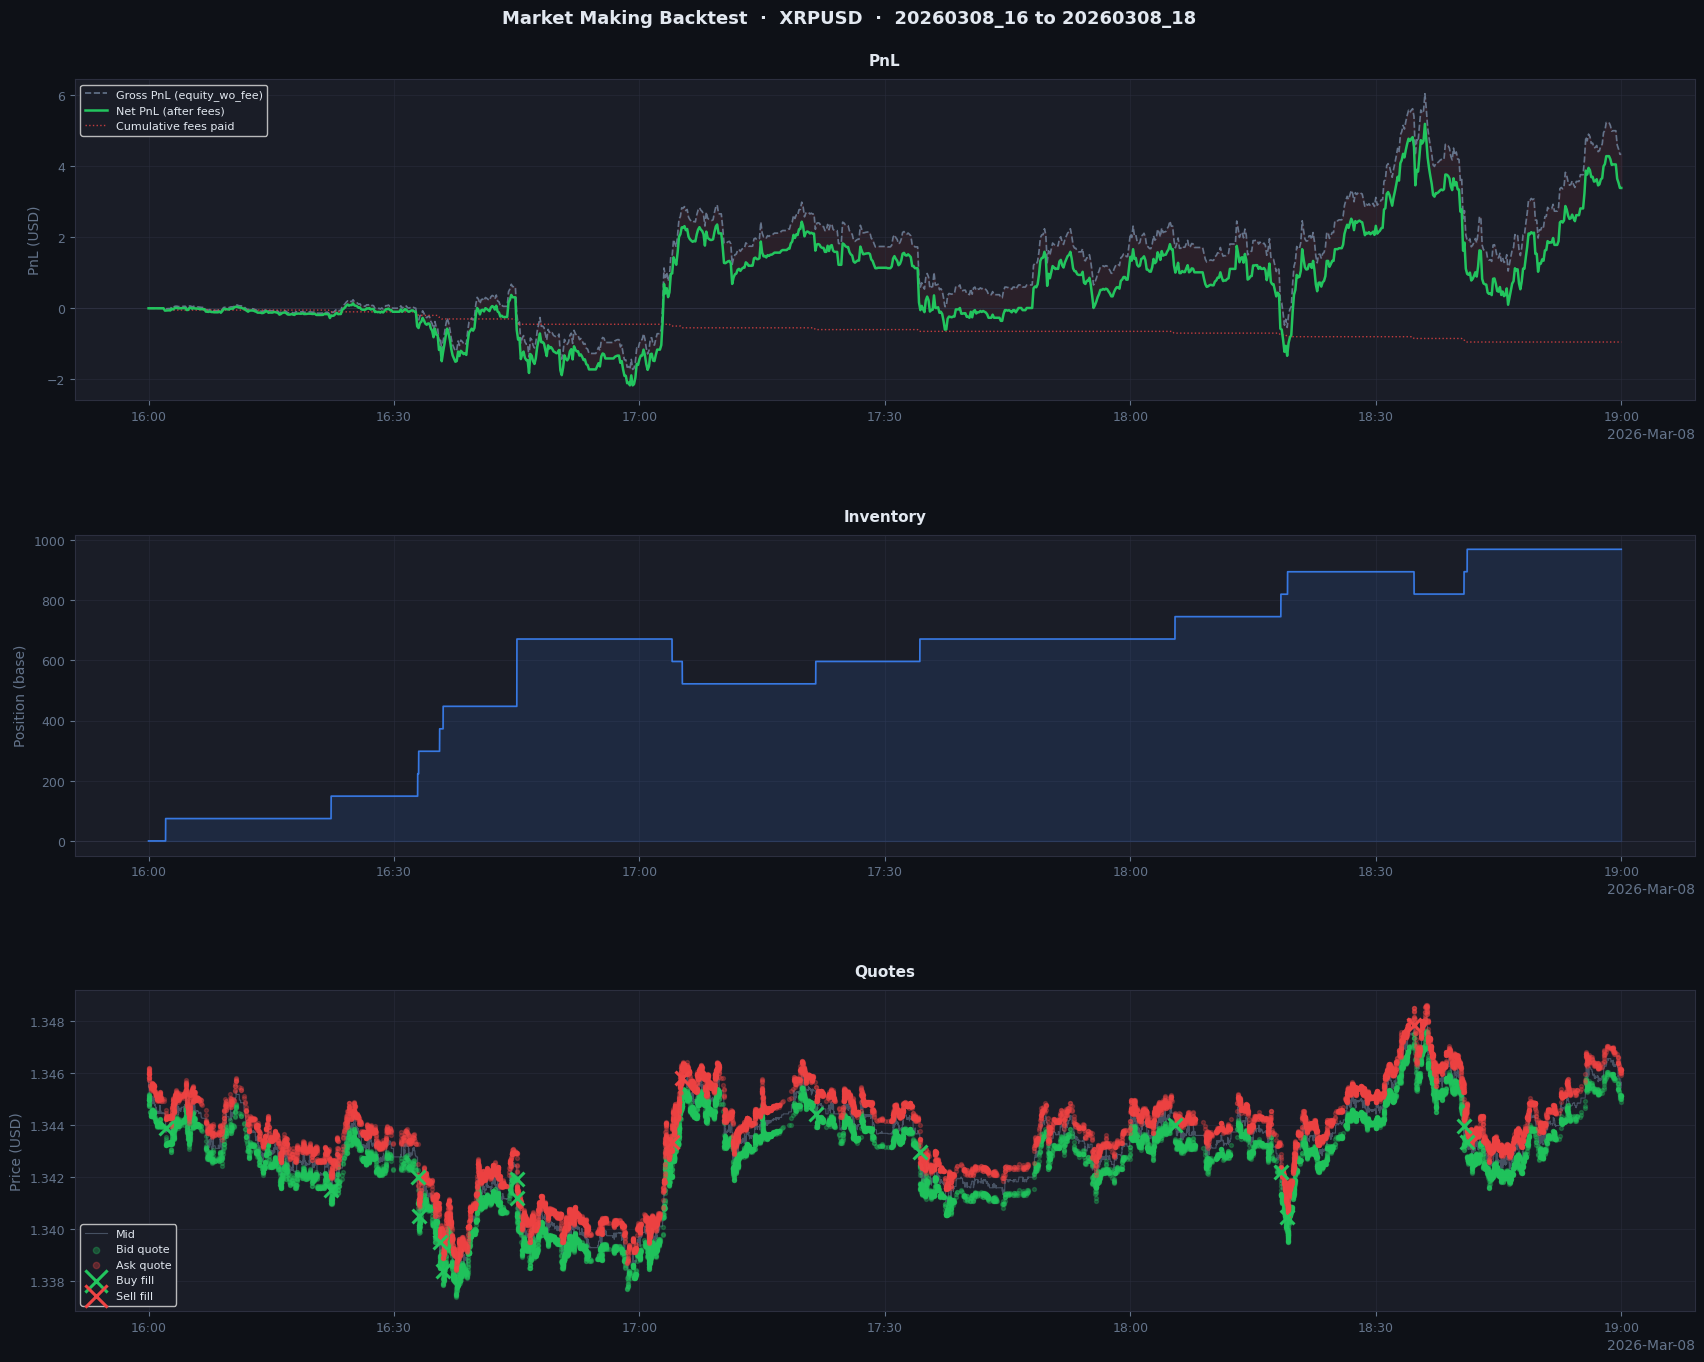

In [5]:
result.plot(downsample=4, figsize=(18, 14), show=True);

## 6. Inspect the fills

`fills_df()` reconstructs the individual fills from the recorder's position changes — useful for sanity-checking execution and computing per-trade statistics.

In [6]:
fills = result.fills_df()
print(f'Total fills: {len(fills)}')
fills.head(10)

Total fills: 18


,datetime,timestamp_ns,side,qty,fill_price,net_cash_flow,fee_at_fill
0,2026-03-08 16:02:04.887000+00:00,1772985724887000000,BUY,74.4000,1.3439,-99.9891,0.0500
1,2026-03-08 16:22:18.587000+00:00,1772986938587000000,BUY,74.5000,1.3416,-99.9477,0.0500
2,2026-03-08 16:32:53.187000+00:00,1772987573187000000,BUY,74.5000,1.3423,-99.9991,0.0500
3,2026-03-08 16:33:00.587000+00:00,1772987580587000000,BUY,74.6000,1.3405,-100.0006,0.0500
4,2026-03-08 16:35:34.187000+00:00,1772987734187000000,BUY,74.6000,1.3395,-99.9260,0.0500
5,2026-03-08 16:35:59.987000+00:00,1772987759987000000,BUY,74.7000,1.3385,-99.9852,0.0500
6,2026-03-08 16:45:00.687000+00:00,1772988300687000000,BUY,74.5000,1.3419,-99.9708,0.0500
7,2026-03-08 16:45:01.287000+00:00,1772988301287000000,BUY,149.0000,1.3412,-199.8388,0.0999
8,2026-03-08 17:03:58.987000+00:00,1772989438987000000,SELL,74.5000,1.3433,100.0736,0.0500
9,2026-03-08 17:05:13.787000+00:00,1772989513787000000,SELL,74.3000,1.3456,99.9796,0.0500


## 7. Hyperparameter search (Bayesian)

`BayesianOptimizer` wraps `scikit-optimize` and integrates with `WalkForwardCV` / `KFoldCV`. The objective function below mirrors the competition's actual scoring rule:

$$\text{Daily Score} = \text{Volume} \times (1 + \text{ROE})^2,\qquad \text{Total Score} = \sum_{\text{top 5 days}} \text{Daily Score}$$

Note that `Return = (Ending - Beginning) / Beginning`, so `2 + Return = 1 + ROE`. The 8-trial run below takes ~1 minute; in production we used 50+ calls with a 3-split walk-forward CV.


In [7]:
import math

def objective(r):
    """Mirrors the competition daily score: Volume * (1 + ROE)^2."""
    vol = r.metrics.get('DailyTradingVolume', 0.0)
    ret = r.metrics.get('Return', -1.0)
    if not (math.isfinite(vol) and math.isfinite(ret)):
        return -1e6
    return vol * (2.0 + ret) ** 2   # (2 + Return) == (1 + ROE)

opt = BayesianOptimizer(
    strategy_class = AvellanedaStoikovStrategy,
    assets         = [asset],
    book_size      = 3_000.0,        # exact Cash Advance from the rules
    fixed = dict(
        interval = 100_000_000,
        order_qty_usd = 100.0,
        max_position_usd = 100_000.0,
        min_half_spread = 0.00001,
    ),
    variable = dict(
        gamma   = (1e-5, 1e-2, 'log-uniform'),
        k       = (100.0, 5000.0, 'log-uniform'),
        horizon = (60.0, 600.0, 'uniform'),
    ),
    objective = objective,
    n_calls   = 8,
    n_initial = 4,
    show_progress = False,
    verbose = False,
)
opt_res = opt.run()
print('Best params:', opt_res.best_params)
print(f'Best score (Volume x (1+ROE)^2): {opt_res.best_score:,.0f}')


2026-05-25 14:16:14 | INFO | mmbt.optimizer.bayesian | ============================================================


2026-05-25 14:16:14 | INFO | mmbt.optimizer.bayesian | OPTIMIZATION START


2026-05-25 14:16:14 | INFO | mmbt.optimizer.bayesian |   Strategy    : AvellanedaStoikovStrategy


2026-05-25 14:16:14 | INFO | mmbt.optimizer.bayesian |   CV          : None (full period)


2026-05-25 14:16:14 | INFO | mmbt.optimizer.bayesian |   n_calls     : 8  (n_initial=4)


...

2026-05-25 14:16:33 | INFO | mmbt.optimizer.bayesian |   gamma                        0.01


2026-05-25 14:16:33 | INFO | mmbt.optimizer.bayesian |   k                            5000


2026-05-25 14:16:33 | INFO | mmbt.optimizer.bayesian |   horizon                      60


2026-05-25 14:16:33 | INFO | mmbt.optimizer.bayesian | ============================================================


Best params: {'interval': 100000000, 'order_qty_usd': 100.0, 'max_position_usd': 100000.0, 'min_half_spread': 1e-05, 'gamma': 0.01, 'k': 4999.999999999999, 'horizon': 60.0}
Best score (Volume x (1+ROE)^2): 1,799,436


## 8. Going further

Things this notebook does **not** cover but which are in the codebase:
- **Multi-asset backtests** (e.g. simultaneous USDC/USD + USDT/USD as in `mm/gtqb_usdc_usdt.py`)
- **Walk-forward CV** with the optimiser (`WalkForwardCV(n_splits=3, train_ratio=0.5)`)
- **Live data collection** from Gemini/Binance WS → hftbacktest NPZ format (`mm/mmbt/data/collect.py`)
- **Live execution bot** with a C++ order-book tracker (`qb/quant_bot.py` + `qb/src/tracker.cpp`) and a real-time analytics dashboard (`qb/dashboard.py`)

See `README.md` for the full project structure and `mm/example_optimizer.py` / `mm/gtqb_xrp_optim.py` for full optimisation scripts.